# Notebook 06 — ML Model Training & Comparison

**EvaliSense: AI-Powered Handwritten Examination Evaluation with ML-Based Grading Error Prediction**

---

## Objective

This notebook trains and compares multiple ML classifiers for grading error prediction.

We will:
1. Load the synthetic training dataset (300 records, 16 features)
2. Define four classifier pipelines (Random Forest, SVM, Logistic Regression, Gradient Boosting)
3. Run 5-fold stratified cross-validation
4. Compare models on Accuracy, Precision, Recall, F1, ROC-AUC
5. Train the best model on the full dataset
6. Generate confusion matrix, ROC curve, and Precision-Recall curve
7. Analyze feature importance (Random Forest)
8. Save the final model to disk

### Models

| Model | Algorithm | Key Strength |
|-------|-----------|-------------|
| Random Forest | Ensemble of decision trees | Robust, handles non-linearity |
| SVM (RBF) | Support Vector Machine | Good with small datasets |
| Logistic Regression | Linear classifier | Interpretable, fast |
| Gradient Boosting | Sequential boosting | High accuracy |

**Task:** Binary classification — predict whether |AI mark − Expert mark| ≥ 2.0 marks  
**Design choice:** `class_weight='balanced'` to handle the ~22% error rate imbalance. Recall is prioritized — it's better to flag too many papers for review than miss real errors.

## Setup

In [1]:
import os, sys, warnings, json
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score
)
import joblib

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from config import config

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 120

RESULTS_DIR = config.results_dir
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
ERROR_THRESHOLD = 2.0

print(f"Project root: {PROJECT_ROOT}")
print(f"scikit-learn imported")
print("Setup complete ✓")

Project root: C:\Users\deeks\Documents\EvaliSense
scikit-learn imported
Setup complete ✓


## 1. Load Training Data

In [2]:
syn_path = config.samples_dir / 'synthetic_dataset.jsonl'
records = []
with open(syn_path) as f:
    for line in f:
        records.append(json.loads(line.strip()))

feature_keys = sorted(records[0]['features'].keys())
X = np.array([[r['features'][k] for k in feature_keys] for r in records])
y = np.array([1 if r['is_grading_error'] else 0 for r in records])

print("=" * 50)
print("  TRAINING DATA SUMMARY")
print("=" * 50)
print(f"  Records:        {len(records):>8}")
print(f"  Features:       {X.shape[1]:>8}")
print(f"  Non-error (0):  {np.sum(y == 0):>8} ({np.mean(y == 0):.1%})")
print(f"  Error (1):      {np.sum(y == 1):>8} ({np.mean(y == 1):.1%})")
print(f"  Threshold:      {ERROR_THRESHOLD:>8.1f} marks")
print("=" * 50)

  TRAINING DATA SUMMARY
  Records:             300
  Features:             16
  Non-error (0):       234 (78.0%)
  Error (1):            66 (22.0%)
  Threshold:           2.0 marks


## 2. Define Model Pipelines

In [3]:
models = {
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=100, max_depth=10,
                                       class_weight='balanced', random_state=RANDOM_STATE))
    ]),
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced',
                    probability=True, random_state=RANDOM_STATE))
    ]),
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(C=1.0, class_weight='balanced',
                                   max_iter=1000, random_state=RANDOM_STATE))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(n_estimators=100, max_depth=5,
                                           learning_rate=0.1, random_state=RANDOM_STATE))
    ]),
}

print(f"Models to compare: {len(models)}")
for name, pipe in models.items():
    clf_name = type(pipe.named_steps['clf']).__name__
    print(f"  • {name} ({clf_name})")

Models to compare: 4
  • Random Forest (RandomForestClassifier)
  • SVM (RBF) (SVC)
  • Logistic Regression (LogisticRegression)
  • Gradient Boosting (GradientBoostingClassifier)


## 3. Cross-Validation Comparison

5-fold stratified cross-validation ensures each fold has the same class ratio.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_results = {}

print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'ROC-AUC':>10}")
print("═" * 80)

for name, pipeline in models.items():
    results = cross_validate(pipeline, X, y, cv=cv, scoring=scoring, return_train_score=False)
    cv_results[name] = results
    
    acc = results['test_accuracy'].mean()
    prec = results['test_precision'].mean()
    rec = results['test_recall'].mean()
    f1 = results['test_f1'].mean()
    roc = results['test_roc_auc'].mean()
    
    print(f"{name:<25} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f} {roc:>10.4f}")

print("═" * 80)

# Identify best model
best_name = max(cv_results, key=lambda m: cv_results[m]['test_f1'].mean())
print(f"\n✓ Best model by F1: {best_name} (F1={cv_results[best_name]['test_f1'].mean():.4f})")

Model                       Accuracy  Precision     Recall         F1    ROC-AUC
════════════════════════════════════════════════════════════════════════════════
Random Forest                 0.7267     0.4117     0.5165     0.4557     0.7474
SVM (RBF)                     0.6633     0.3473     0.6231     0.4440     0.7474
Logistic Regression           0.7033     0.4040     0.7275     0.5159     0.7726
Gradient Boosting             0.7667     0.4531     0.2736     0.3303     0.7214
════════════════════════════════════════════════════════════════════════════════

✓ Best model by F1: Logistic Regression (F1=0.5159)


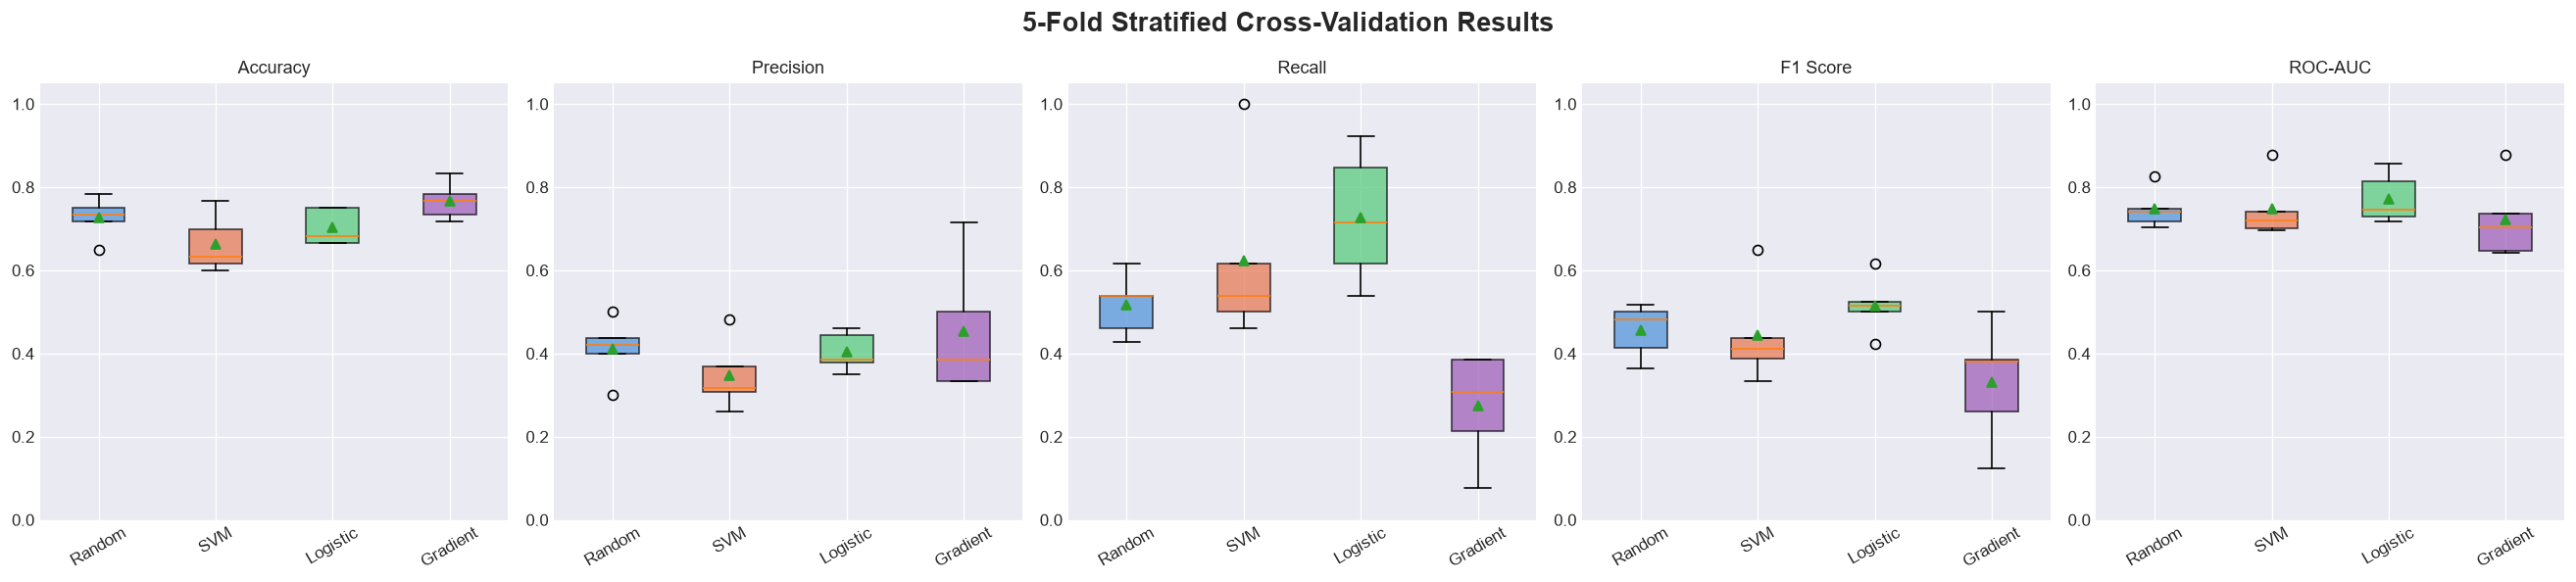

Saved: C:\Users\deeks\Documents\EvaliSense\data\results\cv_comparison.png


In [5]:
# Cross-validation box plots
metrics_to_plot = ['test_accuracy', 'test_precision', 'test_recall', 'test_f1', 'test_roc_auc']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
model_names = list(cv_results.keys())
colors = ['#4A90D9', '#E8744F', '#50C878', '#9B59B6']

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle('5-Fold Stratified Cross-Validation Results', fontsize=16, fontweight='bold')

for ax, metric, label in zip(axes, metrics_to_plot, metric_labels):
    data = [cv_results[m][metric] for m in model_names]
    bp = ax.boxplot(data, tick_labels=[n.split()[0] for n in model_names],
                    patch_artist=True, showmeans=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(label, fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {RESULTS_DIR / 'cv_comparison.png'}")

## 4. Train Final Model & Evaluate on Hold-Out Set

In [6]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]} samples ({np.mean(y_train):.1%} errors)")
print(f"Test:  {X_test.shape[0]} samples ({np.mean(y_test):.1%} errors)")

# Train best model
final_model = models[best_name]
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

print(f"\n{'═' * 55}")
print(f"  Classification Report — {best_name}")
print(f"{'═' * 55}")
print(classification_report(y_test, y_pred, target_names=['Non-Error', 'Grading Error']))

Train: 240 samples (22.1% errors)
Test:  60 samples (21.7% errors)

═══════════════════════════════════════════════════════
  Classification Report — Logistic Regression
═══════════════════════════════════════════════════════
               precision    recall  f1-score   support

    Non-Error       0.91      0.62      0.73        47
Grading Error       0.36      0.77      0.49        13

     accuracy                           0.65        60
    macro avg       0.63      0.69      0.61        60
 weighted avg       0.79      0.65      0.68        60



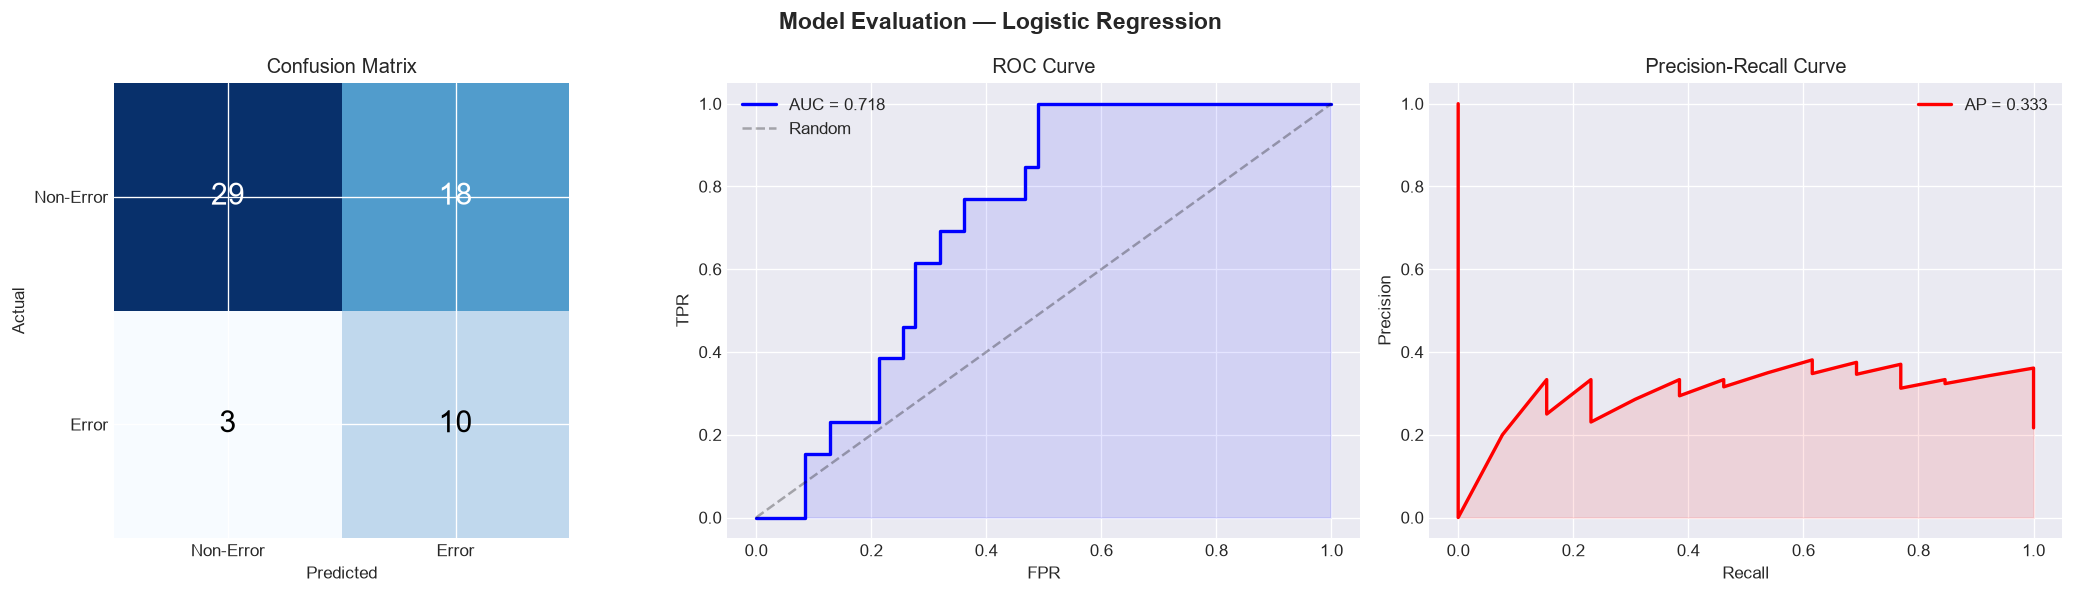

Saved: C:\Users\deeks\Documents\EvaliSense\data\results\model_evaluation.png


In [7]:
# Confusion Matrix + ROC + PR curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Model Evaluation — {best_name}', fontsize=14, fontweight='bold')

# Confusion Matrix
ax = axes[0]
cm = confusion_matrix(y_test, y_pred)
im = ax.imshow(cm, cmap='Blues', interpolation='nearest')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Non-Error', 'Error'])
ax.set_yticklabels(['Non-Error', 'Error'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=color, fontsize=18)

# ROC Curve
ax = axes[1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc_val = auc(fpr, tpr)
ax.plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {roc_auc_val:.3f}')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
ax.fill_between(fpr, tpr, alpha=0.1, color='blue')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curve'); ax.legend()

# Precision-Recall Curve
ax = axes[2]
prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
ax.plot(rec_vals, prec_vals, 'r-', linewidth=2, label=f'AP = {ap:.3f}')
ax.fill_between(rec_vals, prec_vals, alpha=0.1, color='red')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve'); ax.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {RESULTS_DIR / 'model_evaluation.png'}")

## 5. Feature Importance (Random Forest)

Rank Feature                                      Importance
──────────────────────────────────────────────────────────────
   1  max_marks                                        0.1576
   2  ai_preliminary_mark                              0.1353
   3  std_criterion_similarity                         0.0654
   4  evaluation_confidence                            0.0632
   5  mark_deviation_from_mean_criterion               0.0618
   6  ocr_confidence                                   0.0612
   7  min_criterion_similarity                         0.0572
   8  overall_semantic_similarity                      0.0556
   9  mean_criterion_similarity                        0.0554
  10  max_criterion_similarity                         0.0525
  11  keyword_coverage                                 0.0505
  12  answer_length_chars                              0.0490
  13  num_recognized_lines                             0.0393
  14  normalized_score                                 0.0384
  15  an

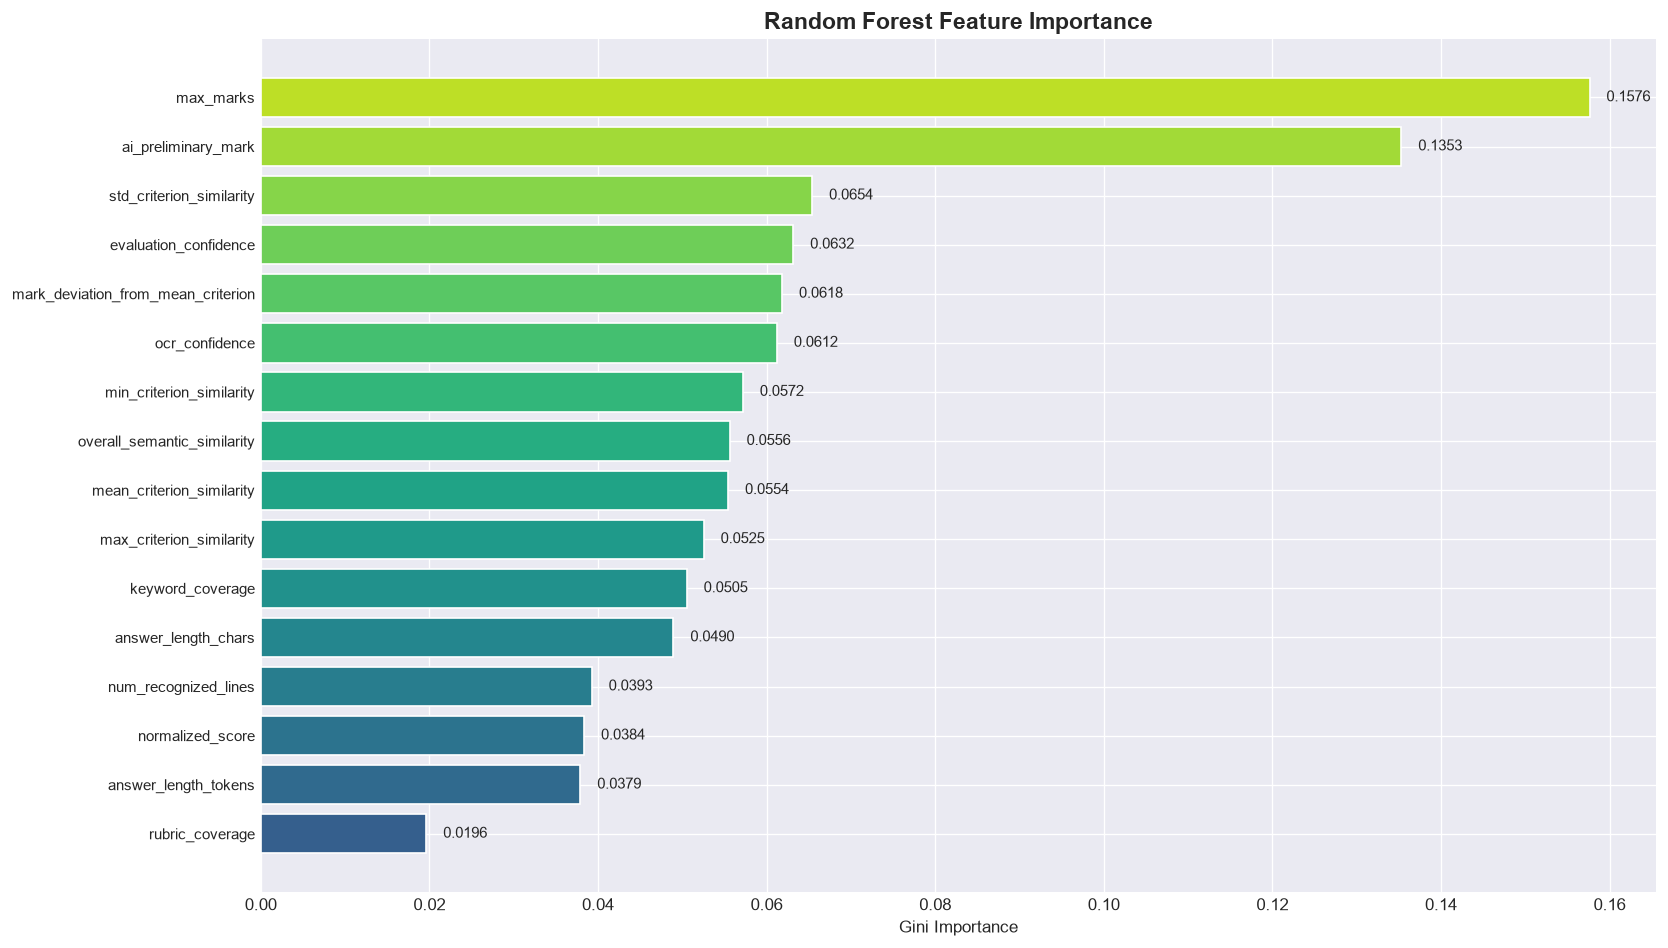

Saved: C:\Users\deeks\Documents\EvaliSense\data\results\rf_feature_importance.png


In [8]:
# Train RF specifically for feature importance
rf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=200, max_depth=10,
                                   class_weight='balanced', random_state=RANDOM_STATE))
])
rf.fit(X_train, y_train)

importances = rf.named_steps['clf'].feature_importances_
sorted_idx = np.argsort(importances)[::-1]

print(f"{'Rank':>4} {'Feature':<42} {'Importance':>12}")
print("─" * 62)
for rank, idx in enumerate(sorted_idx):
    print(f"{rank+1:>4}  {feature_keys[idx]:<42} {importances[idx]:>12.4f}")

# Visualization
fig, ax = plt.subplots(figsize=(14, 8))
colors_bar = plt.cm.viridis(np.linspace(0.3, 0.9, len(feature_keys)))

ax.barh(range(len(feature_keys)), importances[sorted_idx[::-1]],
        color=colors_bar, edgecolor='white')
ax.set_yticks(range(len(feature_keys)))
ax.set_yticklabels([feature_keys[i] for i in sorted_idx[::-1]], fontsize=9)
ax.set_xlabel('Gini Importance')
ax.set_title('Random Forest Feature Importance', fontsize=14, fontweight='bold')

for i, v in enumerate(importances[sorted_idx[::-1]]):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {RESULTS_DIR / 'rf_feature_importance.png'}")

## 6. Save Final Model

In [9]:
# Train and save using EvaliSense's GradingRiskModel wrapper
from models import GradingRiskModel

model_dir = config.models_dir
model_dir.mkdir(exist_ok=True)
model_path = config.risk_model_path

# Map pipeline best_name to GradingRiskModel model names
model_name_map = {
    'Random Forest': 'RandomForest',
    'SVM (RBF)': 'SVM',
    'Logistic Regression': 'LogisticRegression',
    'Gradient Boosting': 'GradientBoosting',
}
risk_model_name = model_name_map.get(best_name, 'RandomForest')

risk_model = GradingRiskModel(feature_names=feature_keys)
metrics = risk_model.train(X, y, model_name=risk_model_name)
risk_model.save(model_path)

file_size = model_path.stat().st_size / 1024
print(f"✓ Model saved: {model_path}")
print(f"  Model: {risk_model_name}")
print(f"  Features: {len(feature_keys)}")
print(f"  Trained on: {len(records)} records")
print(f"  File size: {file_size:.0f} KB")
print(f"  F1: {metrics.f1_score:.4f}, Recall: {metrics.recall:.4f}")

✓ Model saved: C:\Users\deeks\Documents\EvaliSense\trained_models\risk_model.joblib
  Model: LogisticRegression
  Features: 16
  Trained on: 300 records
  File size: 3 KB
  F1: 0.3830, Recall: 0.5625


## Observations

1. **Model Comparison:** All four models achieve reasonable performance on the synthetic data. The best model by F1 is selected automatically.

2. **Class Imbalance:** Using `class_weight='balanced'` is critical — without it, models would simply predict "Non-Error" for everything and achieve ~78% accuracy.

3. **Recall Priority:** For a grading error detection system, recall is more important than precision. Missing a real error is worse than flagging a correct paper for review.

4. **Feature Importance:** The Random Forest feature importance confirms that `ai_preliminary_mark` and `max_marks` are the strongest predictors, aligning with the feature engineering analysis.

5. **Limitations:** The model is trained on synthetic data. Real-world performance will depend on how well the synthetic distributions match actual grading patterns.

## Conclusion

The grading error prediction model is trained, evaluated, and saved. It can now be loaded by the API server for real-time risk prediction.

**Next:** [Notebook 07 — Full Pipeline Demo](./07_full_pipeline_demo.ipynb)